In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/amazon-sales-dataset/amazon_sales_dataset.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("/kaggle/input/amazon-sales-dataset/amazon_sales_dataset.csv")

In [4]:
df.head(8)

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52
1,2,2023-03-12,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28
3,4,2022-04-17,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64
4,5,2022-03-13,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72
5,6,2023-12-02,1777,Sports,385.17,30,3,Asia,Wallet,3.8,489,269.62,808.86
6,7,2022-01-21,4068,Books,15.78,0,5,Asia,UPI,1.6,415,15.78,78.90
7,8,2023-09-07,3537,Fashion,111.59,30,4,Middle East,UPI,3.4,143,78.11,312.44


In [5]:
df.dtypes

order_id              int64
order_date           object
product_id            int64
product_category     object
price               float64
discount_percent      int64
quantity_sold         int64
customer_region      object
payment_method       object
rating              float64
review_count          int64
discounted_price    float64
total_revenue       float64
dtype: object

In [6]:
df['order_date'] = pd.to_datetime(df['order_date'])

In [7]:
df.dtypes

order_id                     int64
order_date          datetime64[ns]
product_id                   int64
product_category            object
price                      float64
discount_percent             int64
quantity_sold                int64
customer_region             object
payment_method              object
rating                     float64
review_count                 int64
discounted_price           float64
total_revenue              float64
dtype: object

In [8]:
print(df.isna().sum())

order_id            0
order_date          0
product_id          0
product_category    0
price               0
discount_percent    0
quantity_sold       0
customer_region     0
payment_method      0
rating              0
review_count        0
discounted_price    0
total_revenue       0
dtype: int64


In [9]:
df.duplicated()[df.duplicated()==True]

Series([], dtype: bool)

In [10]:
print("Shape (rows, columns): ", df.shape,"\n")

Shape (rows, columns):  (50000, 13) 



In [11]:
print("number of rows: ", df.shape[0])
print("number of columns: ", df.shape[1])

number of rows:  50000
number of columns:  13


In [12]:
df.describe(include='all')

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
count,50000.000000,50000,50000.000000,50000,50000.000000,50000.000000,50000.000000,50000,50000,50000.000000,50000.000000,50000.000000,50000.000000
unique,NaN,NaN,NaN,6,NaN,NaN,NaN,4,5,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,Beauty,NaN,NaN,NaN,Asia,Wallet,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,8465,NaN,NaN,NaN,12526,10106,NaN,NaN,NaN,NaN
mean,25000.500000,2022-12-31 10:47:16.800000256,2986.848740,NaN,252.507260,13.340700,2.999400,NaN,NaN,2.996316,249.329280,218.886566,657.331475
min,1.000000,2022-01-01 00:00:00,1000.000000,NaN,5.010000,0.000000,1.000000,NaN,NaN,1.000000,0.000000,3.530000,3.840000
25%,12500.750000,2022-07-02 00:00:00,1983.000000,NaN,127.840000,5.000000,2.000000,NaN,NaN,2.000000,125.000000,109.680000,240.320000
50%,25000.500000,2023-01-02 00:00:00,2983.000000,NaN,252.970000,10.000000,3.000000,NaN,NaN,3.000000,250.000000,215.805000,505.410000
75%,37500.250000,2023-07-02 00:00:00,3989.000000,NaN,376.335000,20.000000,4.000000,NaN,NaN,4.000000,374.000000,322.702500,968.970000
max,50000.000000,2023-12-31 00:00:00,4999.000000,NaN,499.990000,30.000000,5.000000,NaN,NaN,5.000000,499.000000,499.910000,2499.550000


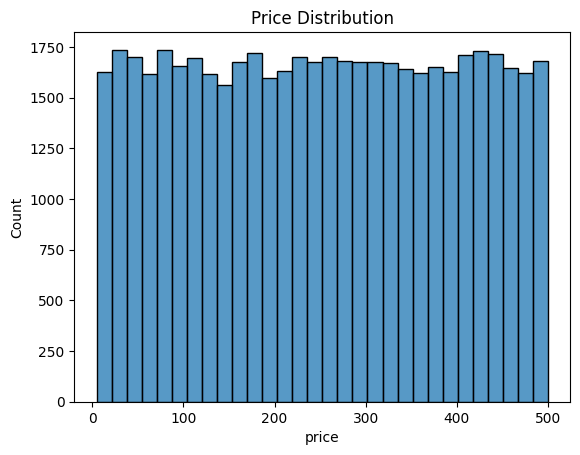

In [13]:
sns.histplot(df['price'], bins=30)
plt.title("Price Distribution")
plt.show()

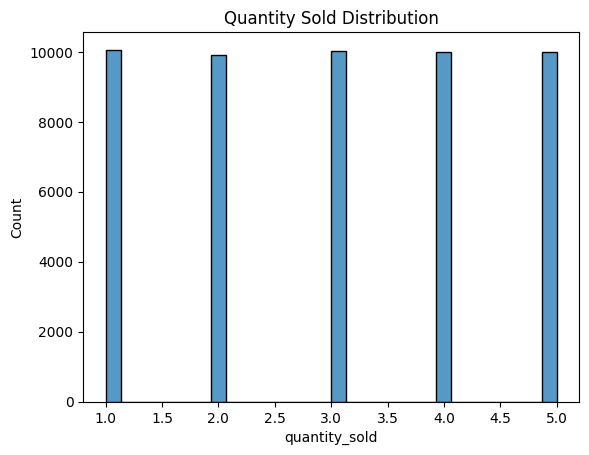

In [14]:
sns.histplot(df['quantity_sold'], bins=30)
plt.title("Quantity Sold Distribution")
plt.show()

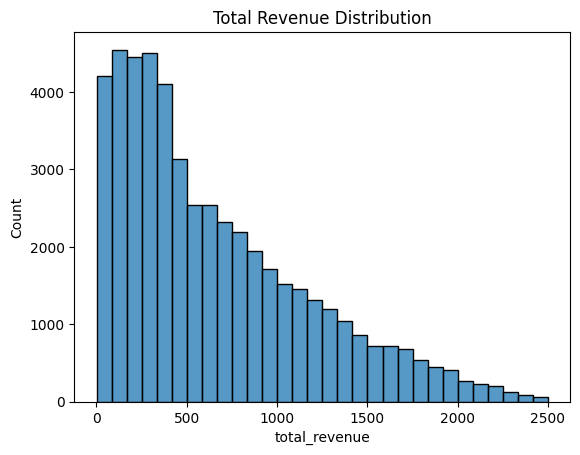

In [15]:
sns.histplot(df['total_revenue'], bins=30)
plt.title("Total Revenue Distribution")
plt.show()

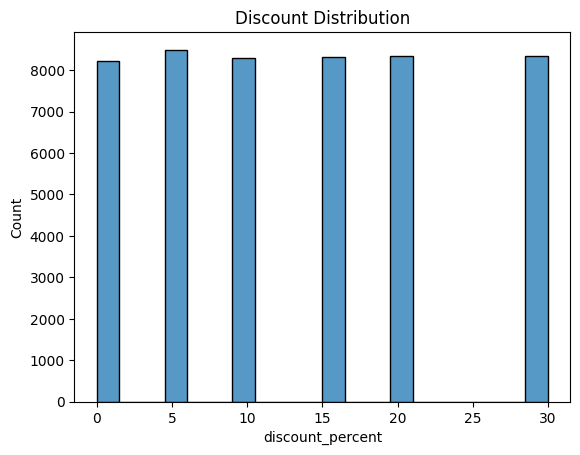

In [16]:
sns.histplot(df['discount_percent'], bins=20)
plt.title("Discount Distribution")
plt.show()

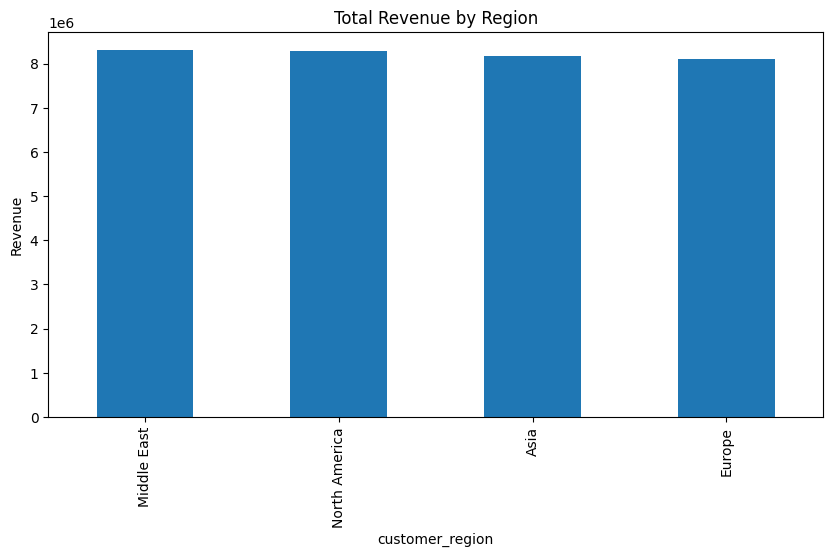

In [17]:
region_revenue = df.groupby('customer_region')['total_revenue'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
region_revenue.plot(kind='bar')
plt.title("Total Revenue by Region")
plt.ylabel("Revenue")
plt.show()

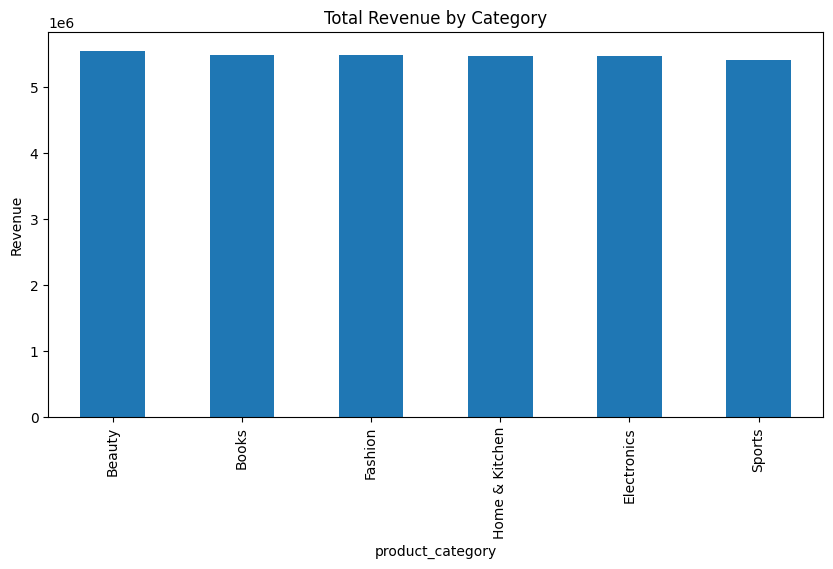

In [18]:
category_revenue = df.groupby('product_category')['total_revenue'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
category_revenue.plot(kind='bar')
plt.title("Total Revenue by Category")
plt.ylabel("Revenue")
plt.show()

In [19]:
category_revenue = df.groupby('product_category')['total_revenue'].sum().sort_values(ascending=False)

category_revenue.head(10)

product_category
Beauty            5550624.97
Books             5484863.03
Fashion           5480123.34
Home & Kitchen    5473132.55
Electronics       5470594.03
Sports            5407235.82
Name: total_revenue, dtype: float64

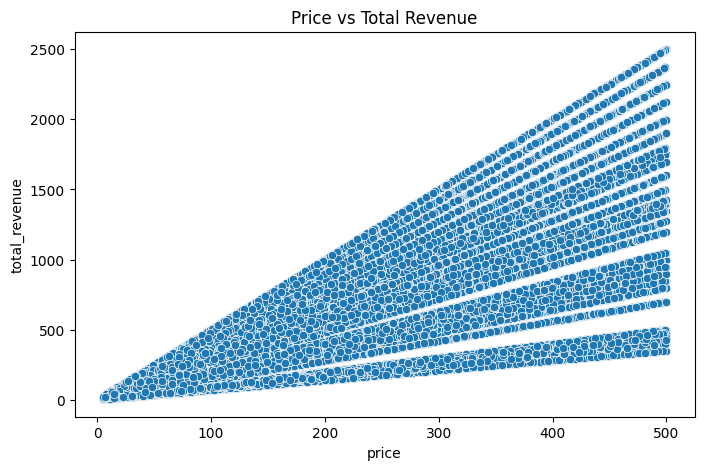

In [20]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='price', y='total_revenue', data=df)
plt.title("Price vs Total Revenue")
plt.show()

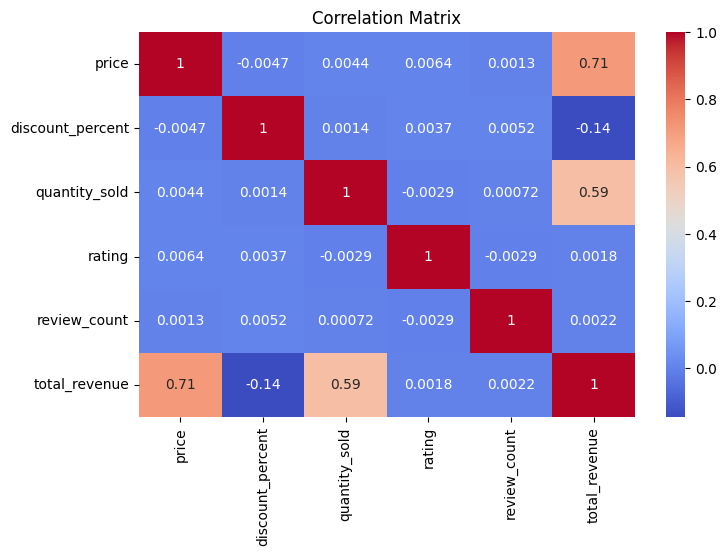

In [21]:
plt.figure(figsize=(8,5))
sns.heatmap(df[['price','discount_percent','quantity_sold','rating','review_count','total_revenue']].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

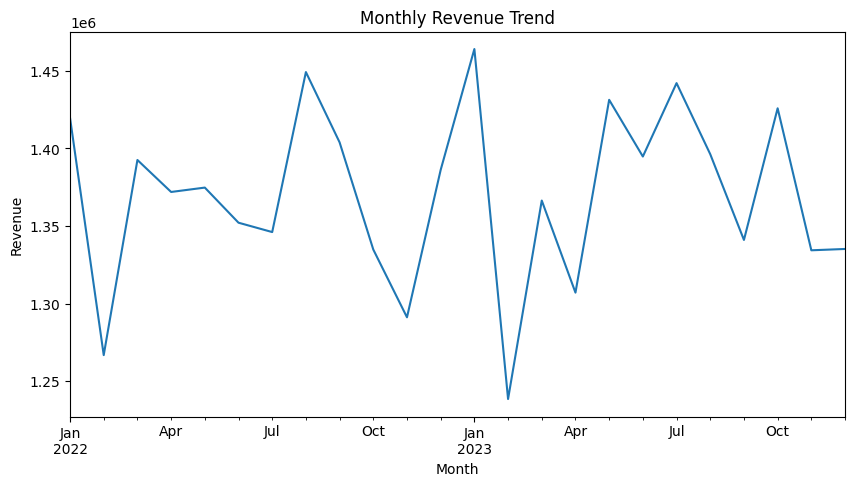

In [22]:
df['Month'] = pd.to_datetime(df['order_date']).dt.to_period('M')
monthly_revenue = df.groupby('Month')['total_revenue'].sum()

plt.figure(figsize=(10,5))
monthly_revenue.plot()
plt.title("Monthly Revenue Trend")
plt.ylabel("Revenue")
plt.show()